<a href="https://colab.research.google.com/github/kaylatucker/CS690_Capstone/blob/main/03_notebooks/06_data_quality_report_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/kaylatucker/CS690_Capstone.git

Cloning into 'CS690_Capstone'...
remote: Enumerating objects: 192, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 192 (delta 85), reused 23 (delta 11), pack-reused 40 (from 4)
Receiving objects: 100% (192/192), 84.71 MiB | 19.68 MiB/s, done.
Resolving deltas: 100% (87/87), done.
Updating files: 100% (40/40), done.


In [ ]:
from pathlib import Path
import pandas as pd

REPO_DIR = Path("/content/CS690_Capstone")
PROCESSED_DIR = REPO_DIR / "02_data" / "processed"

orders = pd.read_csv(PROCESSED_DIR / "orders_clean.csv")
items = pd.read_csv(PROCESSED_DIR / "order_items_clean.csv")
reviews = pd.read_csv(PROCESSED_DIR / "order_reviews_clean.csv")
products = pd.read_csv(PROCESSED_DIR / "products_clean.csv")
order_summary = pd.read_csv(PROCESSED_DIR / "order_item_summary.csv")
seller_metrics = pd.read_csv(PROCESSED_DIR / "seller_metrics.csv")
customer_experience = pd.read_csv(PROCESSED_DIR / "customer_experience.csv")

datasets = {
    "Orders": orders,
    "Order Items": items,
    "Reviews": reviews,
    "Products": products,
    "Order Summary": order_summary,
    "Seller Metrics": seller_metrics,
    "Customer Experience": customer_experience
}

for name, df in datasets.items():
    print(name, df.shape)

Orders (99441, 11)
Order Items (112650, 7)
Reviews (99224, 7)
Products (32951, 10)
Order Summary (98666, 5)
Seller Metrics (3095, 16)
Customer Experience (99441, 36)


In [ ]:
data_dimensions = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": len(df),
        "Columns": df.shape[1]
    }
    for name, df in datasets.items()
])

display(data_dimensions)

,Dataset,Rows,Columns
0,Orders,99441,11
1,Order Items,112650,7
2,Reviews,99224,7
3,Products,32951,10
4,Order Summary,98666,5
5,Seller Metrics,3095,16
6,Customer Experience,99441,36


In [ ]:
important_fields = [
    "review_score",
    "delivery_days",
    "delivery_delay_days",
    "late_delivery_flag",
    "order_value",
    "freight_total",
    "freight_percentage",
    "primary_category",
    "seller_order_count",
    "seller_state",
    "customer_state"
]

missing_summary = pd.DataFrame({
    "Missing Count": customer_experience[important_fields].isna().sum(),
    "Missing Percent": (
        customer_experience[important_fields].isna().mean() * 100
    ).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing_summary)

,Missing Count,Missing Percent
delivery_days,2965,2.98
delivery_delay_days,2965,2.98
late_delivery_flag,2965,2.98
primary_category,2164,2.18
seller_order_count,2053,2.06
seller_state,2053,2.06
freight_percentage,775,0.78
order_value,775,0.78
freight_total,775,0.78
review_score,768,0.77


## Summary statistics

In [ ]:
summary_fields = [
    "review_score",
    "delivery_days",
    "delivery_delay_days",
    "order_value",
    "freight_total",
    "freight_percentage",
    "items_per_order"
]

summary_statistics = (
    customer_experience[summary_fields]
    .describe()
    .T
    .round(2)
)

display(summary_statistics)

,count,mean,std,min,25%,50%,75%,max
review_score,98673.0,4.09,1.35,1.00,4.00,5.00,5.00,5.00
delivery_days,96476.0,12.56,9.55,0.53,6.77,10.22,15.72,209.63
delivery_delay_days,96476.0,-11.18,10.19,-146.02,-16.24,-11.95,-6.39,188.98
order_value,98666.0,137.75,210.65,0.85,45.90,86.90,149.90,13440.00
freight_total,98666.0,22.82,21.65,0.00,13.85,17.17,24.04,1794.96
freight_percentage,98666.0,30.84,31.48,0.00,13.19,22.44,38.02,2144.71
items_per_order,98666.0,1.14,0.54,1.00,1.00,1.00,1.00,21.00


In [ ]:
print("Review score distribution:")
display(
    customer_experience["review_score"]
    .value_counts()
    .sort_index()
    .to_frame("orders")
)

print("\nLate-delivery distribution:")
display(
    customer_experience["late_delivery_flag"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("orders")
)

Review score distribution:


,orders
review_score,
1.000000,11316
1.500000,8
2.000000,3125
2.500000,34
3.000000,8136
3.333333,1
3.500000,25
4.000000,19018
4.333333,1



Late-delivery distribution:


,orders
late_delivery_flag,
0.0,88649
1.0,7827
NaN,2965


## Review-score distribution

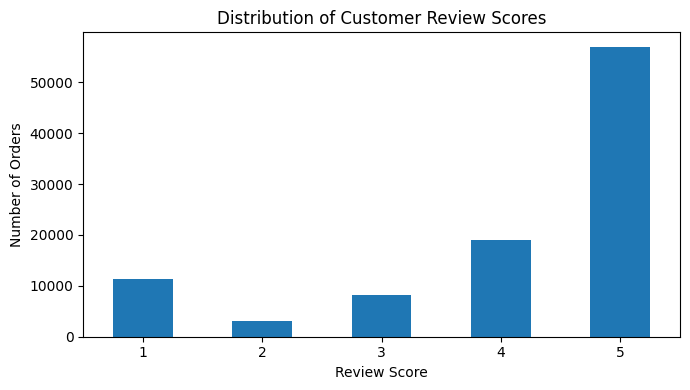

In [ ]:
import matplotlib.pyplot as plt

review_score_display = (
    customer_experience["review_score"]
    .round()
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

plt.figure(figsize=(7, 4))
review_score_display.plot(kind="bar")

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Delivery performance and customer satisfaction

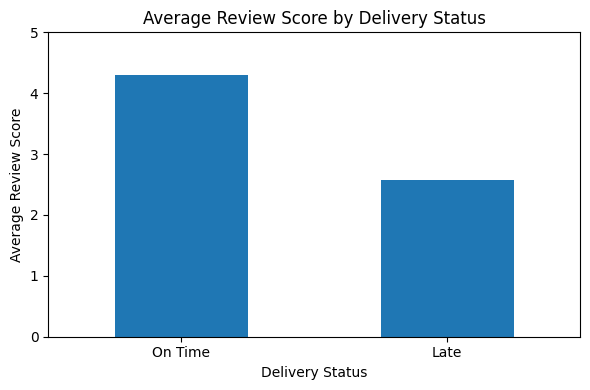

,average_review_score
On Time,4.29
Late,2.57


In [ ]:
review_by_late = (
    customer_experience
    .dropna(subset=["late_delivery_flag", "review_score"])
    .groupby("late_delivery_flag")["review_score"]
    .mean()
)

review_by_late.index = ["On Time", "Late"]

plt.figure(figsize=(6, 4))
review_by_late.plot(kind="bar")

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

display(review_by_late.to_frame("average_review_score").round(2))

## Data quality


In [ ]:
quality_issues = pd.DataFrame({
    "Issue": [
        "Orders without review score",
        "Orders without item records",
        "Orders without delivery date",
        "Multi-seller orders",
        "Duplicate raw geolocation rows",
        "Distinct duplicated review IDs"
    ],
    "Count": [
        768,
        775,
        2965,
        1278,
        261831,
        789
    ],
    "Handling": [
        "Retained as missing",
        "Retained; item-derived fields remain missing",
        "Delivery measures retained as missing",
        "No single-seller characteristics assigned",
        "Reduced to one ZIP-level representative coordinate",
        "Not removed solely because review ID repeated"
    ]
})

display(quality_issues)

,Issue,Count,Handling
0,Orders without review score,768,Retained as missing
1,Orders without item records,775,Retained; item-derived fields remain missing
2,Orders without delivery date,2965,Delivery measures retained as missing
3,Multi-seller orders,1278,No single-seller characteristics assigned
4,Duplicate raw geolocation rows,261831,Reduced to one ZIP-level representative coordi...
5,Distinct duplicated review IDs,789,Not removed solely because review ID repeated


review_score_display,1,2,3,4,5
delivery_status,,,,,
On Time,6.56,2.66,7.99,20.41,62.38
Late,46.11,7.95,11.34,12.40,22.20


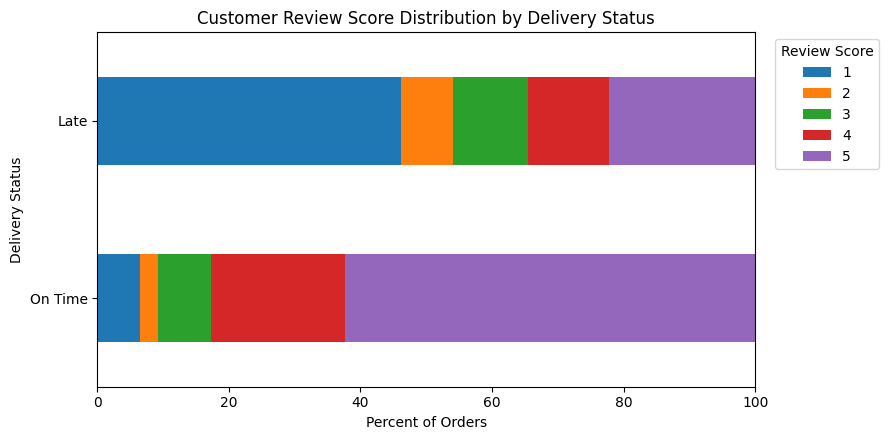

In [ ]:

review_delivery = (
    customer_experience
    .dropna(subset=["review_score", "late_delivery_flag"])
    .copy()
)


review_delivery["review_score_display"] = (
    review_delivery["review_score"]
    .round()
    .clip(1, 5)
    .astype(int)
)

review_delivery["delivery_status"] = (
    review_delivery["late_delivery_flag"]
    .map({
        0: "On Time",
        1: "Late"
    })
)

review_mix = (
    pd.crosstab(
        review_delivery["delivery_status"],
        review_delivery["review_score_display"],
        normalize="index"
    ) * 100
)

review_mix = (
    review_mix
    .reindex(["On Time", "Late"])
    .reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
)

display(review_mix.round(2))

ax = review_mix.plot(
    kind="barh",
    stacked=True,
    figsize=(9, 4.5)
)

ax.set_title("Customer Review Score Distribution by Delivery Status")
ax.set_xlabel("Percent of Orders")
ax.set_ylabel("Delivery Status")
ax.set_xlim(0, 100)

ax.legend(
    title="Review Score",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

AI Assistance Statement
Google Gemini was used to assist with drafting and formatting some Markdown cells in this notebook. I reviewed and edited the generated text before including it. I also used Google Colab’s code-completion/autocomplete feature when it suggested portions of code that matched what I intended to write. All code, analyses, and results were reviewed and verified by me.

Google. (2026). Gemini [Large language model]. https://gemini.google.com/
